In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Credit Risk Analysis using PD, LGD, EAD and Stress testing

## 1. Introduction

Credit risk refers to the possibility that a borrower will fail to meet their financial obligations. It is one of the most important risks faced by financial institutions, as it directly affects probability and financial stability.

The objective of this project is to analyze credit risk using a dataset of loan applications and to estimate the key components of risk: **Probability of Default (PD), Loss Given Default (LGD), and Exposure at Default (EAD).** These components are used to calculate the **Expected Loss (EL)** of the credit portfolio.

In addition to the baseline analysis, the project also explores how credit risk behaves under different economic conditions through **stress testing** and examines the sensitivity of expected loss changes in its main drivers.

The results aim to provide insights into how borrower characteristics and macroeconomic conditions influence overall credit risk.

## 2. Dataset Description

The dataset used in this project contains information about borrowers and their loan characteristics. It includes demographic, financial and loan-related variables that are relevant for assessing credit risk.

**Key Variables**

| Variable    | Description |
| ----------- | ----------- |
| person_age  | Age of the borrower    |
| person_income | Annual income of the borrower     |
| person_home_ownership    | Home owenership status (RENT, OWN, MORTGAGE, OTHER)    |
| person_emp_length  | Employment lenght (years)    |
| loan_intent | Purpose of the loan     |
| loan_grade    | Credit grade assigned to the borrower   |
| loan_amnt  | Loan amount    |
| loan_int_rate | Interest rate of the loan     |
| loan_status    | Default indicator for the loan(1 = default, 0 = non-default)    |
| loan_percent_income  | Loan income    |
| cb_person_default_on_file |  Default indicator for the person (Y = default, N = non-default)    |
| cb_loan_term    | Loan term (in years)    |

In [157]:
data = pd.read_csv("credit_risk_dataset_modified_final_v3.csv")
pd.options.display.max_columns = None
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_loan_term
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0,0.57,N,30
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


**Additional variables (Created for Analysis)**

To support the credit risk modeling process, additional variables are introduced:
- **cb_person_default_on_file** is equal to N when **loan_status** is equal to 0 and **cb_person_default_on_file** is equal to Y when **loan_status** is equal to 1
- **remaining_balance:** simulated outstanding loan amount, representing the unpaid portion of the loan
- **EAD (Exposure at Default):** approximated using the remaining balance
- **LGD (Loss Given Default):** calculated as the ratio of remaining balance to loan amount

**Dataset Purpose**

Dataset is used to:
- estimate default probabilities
- analyze risk across different borrowers segments
- evaluate potential losses
- simulate how risk evolves under different economic conditions


## 3. Methodology

This section outlines the methodology used to estimate the key components of the credit risk: **Probability of Default (PD), Loss Given Default (LGD), and Exposure at Default (EAD).**

 * **Probability of Default (PD)**

The **Probability of Default (PD)** is estimated using the historical defaul rate in the dataset. It is calculated as the proportion of borrowers who have defaulted: $$ PD = \frac{\text{Number of Defaults}}{\text{Total Number of Borrowers}} $$

This approach provides a baseline estimate of default likelihood across the entire portfolio.

 * **Exposure at Default (EAD)**
  
The dataset does not contain a direct measure of outstanding loan exposures. Therefore, a new variable calles **remaining_balance** is introduced to approximate the unpaid portion of each loan.

The remaining balance is generated as a proportion of the original loan amount, ensuring that it is always lower total loan value.

$$EAD = \text{remaining balance}$$

This approximation allows for a realistic estimation of exposure at the moment of default.

 * **Loss Given Default (LGD)**
   
The **Loss Given Default (LGD)** represents the proportion of exposure that is not recovered in case of default.

Since recovery data is not available, LGD is approximated using the ratio of the remaining balance to the original loan amount:

 $$ LGD = \frac{\text{remaining balance}}{\text{loan amount}} $$

This approach assumes that the remaining balance refects the potential loss at default.

 * **Expected Loss**

The **Expected Loss** combines all three components and represents the total expected financial loss:
$$ EL = PD \times LGD \times EAD $$
This metric is used to quantify the overall credit risk of the portfolio.

 * **Stress testing**
   
To evaluate the impact of adverse economic conditions, stress scenarios are intriduced. This scenarios assume increase in PD, LGD and EAD to simulate the effect of an economic downturn.


## 4. Exploratory Data Analysis (EDA)

Before calculating the risk components, an exploratory data analysis is performed to better understand the structure of the dataset and identify patterns related to credit risk.

**Loan Term Distribution**

The following boxplot illustrates the distribution of loan terms (in years) within the dataset. This visualization provides a clear overview of how loan durations are spread, highlighting key statistical measures such as the median, variability and the presence of extreme values.

Analyzing the distribution of loan terms is important for understanding the structure of the credit portfolio, as the length of a loan can significantly influence the level of credit risk. Short-term and long-term loans often carry different risk profiles. Making this variable essential for further risk segmentation and analysis.

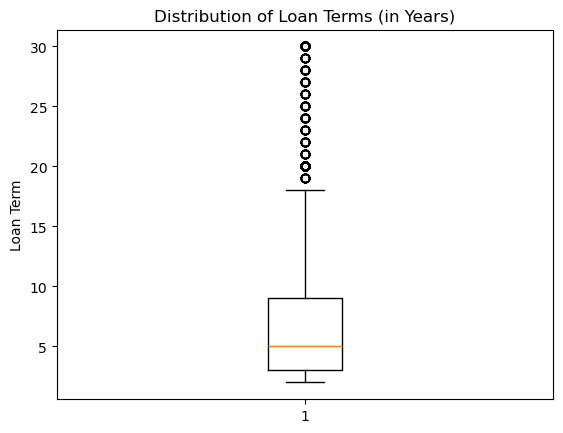

In [159]:
plt.boxplot(data["cb_loan_term"])
plt.title("Distribution of Loan Terms (in Years)")
plt.ylabel("Loan Term")
plt.show()

In [160]:
print(f"Mean: |{load_term_mean}|")
print(f"Median: |{load_term_median}|")
print(f"Standard deviation: |{load_term_std}|")

Mean: |10.925754273963353|
Median: |7.0|
Standard deviation: |9.349046223176252|


***The graph represents the distribution of loan terms (in years), with a maximum duration reaching 30 years.***<br>
1. Central Dependancy
- The median is 7 years, which means: half of the loans have a duration below 7 years
- The mean is higher (~11 years), indicating: the presence of long-term loans(outliers)
2. Variability
  - The standard deviation(~9.35) is relatively high - this suggests a wide spread in loan durations
  - Loan terms range from:<br>
        ** short-term (~ 2-4 years)<br>
        ** to long-term (~30 years)
3. Boxplot analysis
- The interquartile range(IQR) shows that most loans fall between: approximately 4 and 15 years
- Lower bound: around 2 years
- Upper bound: extends up to 30 years
4. Skewness
- The distribution is right-skewed (positively skewed) - a small number of long-term loans (20-30 years) pull the means upward

The analysis shows that most loans are concentrated in short-to medium-term ranges, while a smaller number of loans extend to long-term periods (up to 30 years). This variation is important, as longer loan terms are generally associated with higher uncertainty and increased credit risk.

## 5. Probability of Default (PD)

The **Probability of Default (PD)** measures the likelihood that borrower will fail to repay their loan. In this analysis PD is estimated using the historical default in the datased: $$ PD = \frac{\text{Number of Defaults}}{\text{Total Number of Borrowers}} $$

In [161]:
person_Y_default = data["cb_person_default_on_file"] == "Y"
count_person_Y_default = person_Y_default.sum()
total_number_borrowers = len(data)
probability_default = count_person_Y_default / total_number_borrowers

**Key results:**

In [162]:
print(f"Number of defaulted borrowers(Y): |{count_person_Y_default}|")
print(f"Total number of borrowers: |{total_number_borrowers}|")
print(f"Calculated PD: |{probability_default}|")

Number of defaulted borrowers(Y): |5745|
Total number of borrowers: |32581|
Calculated PD: |0.17632976274515821|


**Interpretation:**
1. Overall risk level
   - A PD of 17.63% indicates that: approximately 1 out of every 6 borrowers in the dataset has defaulted
   - This suggests a moderate to relatively high credit riskwithin the portfolio
2. Credit portfolio quality
   - The result implies that the dataset includes:
      * a significant portion of risky borrowers
      * potentially lower credit quality segments (e.g. low income, high interest loans)
3. Business implication
   - From a banking perspective a PD close to 18% would require:
      * stricter credit approval criteria
      * higher interest rates to compensate for risk
      * or stronger risk management strategies
4. Model perspective
    - This PD serves as a baseline(unconditional PD): it does not yet accoiunt for borrower characteristics(age, income, loan type, ets.)

The following analysis examines how Probability of Default(PD) varies across different categories of home ownership. By grouping borrowers based on their housing status - MORTGAGE, OWN, RENT and OTHER - we can better understand how financial stability and asset ownership influence credit risk.

Home ownership is considered an important indicator of a borrower's stability and access to assets. Therefore, analyzing PD across these groups provides valuable insights into how housing conditions relate to the likelihood of default. 

In [163]:
pd_home = data.groupby("person_home_ownership")["loan_status"].mean()
pd_home_df = pd_home.reset_index()
pd_home_df.columns = ["Home Ownership" , "PD"]
pd_home_df["PD (%)"] = (pd_home_df["PD"] * 100).round(2)
pd_home_df.drop("PD", axis=1, inplace=True)
pd_home_df

,Home Ownership,PD (%)
0,MORTGAGE,14.83
1,OTHER,27.10
2,OWN,17.18
3,RENT,19.93


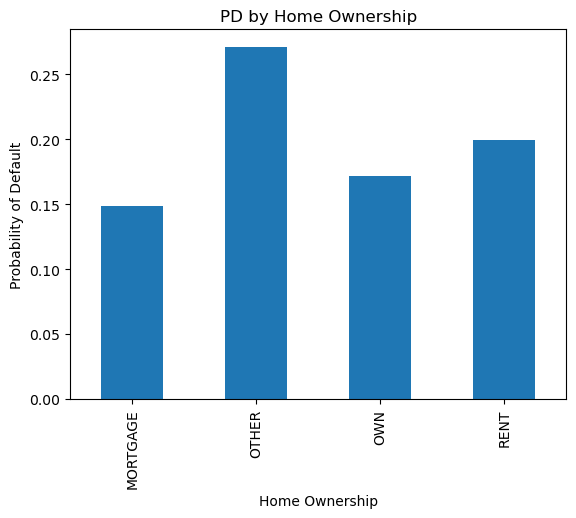

In [164]:
pd_home.plot(kind="bar")
plt.title("PD by Home Ownership")
plt.ylabel("Probability of Default")
plt.xlabel("Home Ownership")
plt.show()

***The analysis shows how default probability varies across different housing statuses.***
1. Highest risk groups
 - Borrowers who rent or fall into the OTHER category show the highest probability of default(~31%)
 - This suggests financial instability, lack of long-term assests, higher vulnerability to economic shocks
2. Moderate risk group
 - Borrowers with a mortage have a moderate PD(~12.6%). This indicates some financial stability but still ongoing financial obligations
3. Lowest risk group
 - Borrowers who own their home have the lowest PD(~7.5%). This reflects: strong financial stability, lower debt burden, higher repayment capacity

The following analysis examines how Probability of Default(PD) varies across different loan terms, ranging from short-term to long-term loans. By grouping borrowers based on the duration of their loans, this analisys provides insight into how the length of a credit agreement influences the likelihood of default.

Loan term is a key factor in credit risk assessment, as longer repayment periods are typically associated with greater uncertainty and exposure to economic changes. Understanding how default risk envolves across different loan durations is essential for identifying risk patterns and improving lending decisions.

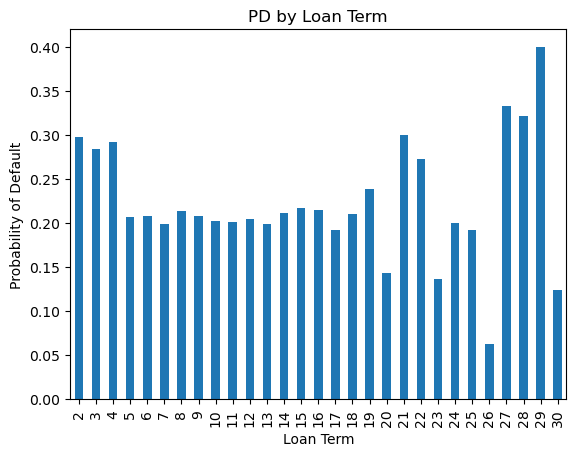

In [136]:
pd_home = data.groupby("cb_loan_term")["loan_status"].mean()
pd_home.plot(kind="bar")
plt.title("PD by Loan Term")
plt.ylabel("Probability of Default")
plt.xlabel("Loan Term")
plt.show()


***The graph shows how the Probaility of Default(PD) varies across different loan terms, ranging from 2 to 30 yeaars.***

**Interpretation:**
1. General trend
 - The PD is not constant across loan terms and shows noticeable variation
 - Most loan terms between 5 and 20 years have relatively stable PD arround ~20 - 22%
2. Short-term loans
 - Very short-term loans (2-4 years) show moderately high PD(~ 28 - 30%)
 - This may indicate:
   * riskier borrowers choosing short-ter, loans
   * or financial pressure leading to short repayment periods
3. Medium-term loans(most stable group)
 - Loan terms between 6 and 18 years show the most stable and moderate PD (~ 20%)
 - This suggests:
   * balanced risk
   * more predictable borrower behavior
4. Long-term loans (high-risk zone)
 - Loan terms above 20 years show increasing volatility and higher PD
 - Some terms(specially around 27-29 years reach PD above 30%-38%)

The following analysis examines how Probability of Default(PD) varies across different income groups in combination with home ownership status. By segmenting borrowers based on both financial capacity (income) amd housing situation, this approach providesa deeper understandiing of credit risk patterns.

Income level reflects a borrower's ability to repay a loan, while home ownership indicates financial stability and asset ownership. Analyzing these two factors together allows for a more comprehensive evaluation of risk, highlighting how different borrowers profiles behave in terms of default probability.


In [137]:
data["income_group"] = pd.qcut(data["person_income"], 4, labels=["Low", "Medium", "High", "Very high"])
pd_combo = data.groupby(["income_group", "person_home_ownership"])["loan_status"].mean().unstack()

C:\Users\cvete\AppData\Local\Temp\ipykernel_3008\46961603.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd_combo = data.groupby(["income_group", "person_home_ownership"])["loan_status"].mean().unstack()


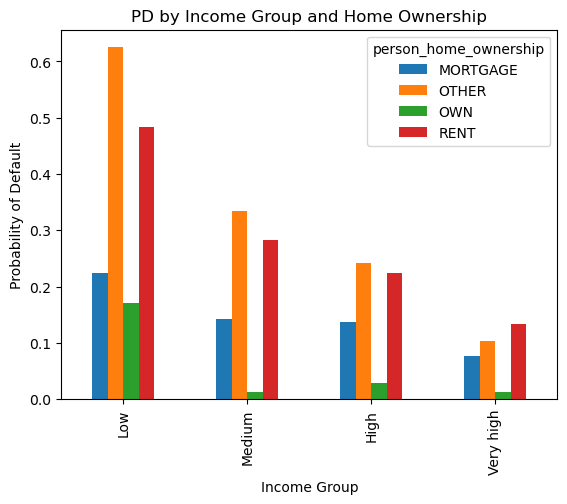

In [138]:
pd_combo.plot(kind="bar")
plt.title("PD by Income Group and Home Ownership")
plt.ylabel("Probability of Default")
plt.xlabel("Income Group")
plt.show()

***The graph presents the Probaility of Default(PD) across different income groups(Low, Medium, High, Very high) combined with home ownership status(MORTGAGE, OTHER, OWN, RENT).***

**Interpretation:**
1. Strong impact of income
 - There is a clear downward trend in PDas income increases:
   * Low income: highest default rates
   * Very high income: lowest default rates
 This confirms that income is a key determinant of credit risk
2. Highest risk segment Even high-income renters can still carry higher risk than homeowners
 - The highest PD is observed for Low income + OTHER (~ 62%)  and Low income + RENT (~48%)
 - This group represents:
   * financially unstable borrowers
   * lack of assets
   * highest vulnerability to default
3. Effect of home ownership
 - Across all income levels:
   * OWN consistently has the lowest PD
   * RENT and OTHER show significantly higher risk
   * MORTGAGE falls in the middle
4. Medium and high income behavior
 - As income increases:
   * PD decreases for all groups
   * but RENT and OTHER remain riskier than OWN
Even high-income renters can still carry higher riskthan homeowners.
5. Most stable group
 - The lowest PD is observedfor Very High income + OWN (~2-3%)
 - This group represents:
   * financially secure borrowers
   * lowest credit risk
   

###  6. Exposure at Risk (EAD)

In this section, Exposure at EAD is calculated to estimate this total amouont of credit exposure at the moment a borrower defaults. EAD represents the outstanding balance that the lender is exposed to if the borrower fails to repay the loan.

Since the dataset does not include a direct measure of the remaining loan balance, a new variable "remaining_balance" is introduced to approximate it.  This value is generated as a random proportion of the original loan amount, ranging between 30% and 80%, to simulate partial repayment over time. 

This approach allows for a practical estimation of EAD, which is key component in creadit risk modeling and is later used in the calculation of expected losses.

In [139]:
data["remaining_balance"] = data["loan_amnt"] * np.random.uniform(0.3, 0.8, len(data))
data["EAD"] = data["remaining_balance"]
data[["loan_amnt", "EAD"]].head()


,loan_amnt,EAD
0,35000,19111.010542
1,1000,355.849440
2,5500,2220.657704
3,35000,26658.008672
4,35000,15908.812771


In [140]:
total_ead = data["EAD"].sum()
average_ead = data["EAD"].mean()
ead_default = data[data["loan_status"] == 1]["EAD"].sum()

**Key Results:**

In [141]:
print(f"Total EAD: |{total_ead}|")
print(f"Average EAD: |{average_ead}|")
print(f"EAD for defaulted loans: |{ead_default}|")

Total EAD: |171648237.31889743|
Average EAD: |5268.3538663299905|
EAD for defaulted loans: |42438152.32648602|


**Interpretation:**
* The total EAD represents the overall exposure of the credit portfolio
* The average EAD shows the typical exposure per borrower
* The EAD for defaulted loans indicates the portion of exposure already affected by defaults

This helps quantify how much capital is at risk in case borrower default. The EAD associated with defaulted loans represents approximately 25% of the total portfolio exposure, indicating a relatively high level of realized credit risk. The bank is exposed to real, not just potential losses, credit risk has already materialized. 

**Comparison with PD**
 * PD ~ 17.6%
 * EAD_default ~ 25% of total EAD<br>
This indicates defaulted loans are not only frequent but also larger in size. From banking perspective , this suggests :
 * elevated credit risk
 * need for:
    * stricter lending criteria
    * improved credit scoring models
    * better risk management strategies

###  7. Loss Given Default (LGD)

In this section, we estimate the **Loss Given Default(LGD)**, which measures the proportion of exposure that is lost when a borrower defaults. Since the dataset does not provide explicit recovery or collateral information, LGD is approximated using the ratio between the remaining loan balance and the total loan amount.

This approach assumes that the remaining balance represents the potential loss at the moment of default. Additionally, LGD is analyzed specifically for defaulted loans in order to better understand the severity of losses within the high-risk segment of the portfolio.

In [142]:
data["LGD"] = data["remaining_balance"] / data["loan_amnt"]
total_lgd = data["LGD"].sum()
print(f"Total LGD (sum): |{total_lgd}|")

Total LGD (sum): |17908.119602976985|


In [143]:
average_lgd = data["LGD"].mean()
print(f"Average LGD (sum): |{average_lgd }|")

Average LGD (sum): |0.5496491698528893|


The average LGD indicates that on average, more than half of the loan amount is lost when exposure remains unpaid.

In [144]:
data_lgd_default = data[data["loan_status"] == 1]["LGD"].sum()
print(f"Total LGD (defaulted loans): |{data_lgd_default}|")

Total LGD (defaulted loans): |3906.960399468542|


In [145]:
average_lgd_default = data[data["loan_status"] == 1]["LGD"].mean()
print(f"Average LGD (defaulted loans): |{average_lgd_default }|")

Average LGD (defaulted loans): |0.5496567810169587|


**Key Interpretation:**

- The LGD for defaulted loans is very close to the overall average LGD
- This suggests:
   * the dataset is consistent in term of loss behavior
   * losses are not significantly different between defaulted and overall exposure distribution

The LGD is considered high and this implies:
 - low recovery rates
 - significant financial impact upon default
 - increased expected losses

For financial institution, this means:
 - More than half of the exposure is typically not recovered
 - Risk management should focus on:
    * reducing default rates (PD)
    * improving recovery processes
    * tightening lending policies

### 8. Expected Loss (EL)

The Expected Loss (EL) combines Probability of Default (PD), Exposure at Default (EAD) to estimate the total financial loss.

The Expected Loss is calculated as:
 $$ EL = PD \times LGD \times EAD $$

Using results:

In [146]:
EL = probability_default*total_lgd*total_ead
print(f"EL: |{EL}|")

EL: |542019557551.25604|


The result indicates that the portfolio carries a substantial level of credit risk driven by the combined effect of default frequency, loss severity and exposure size. 

The portfolio shows:
 - Moderate PD - defaults occur with noticeable frequency
 - High LGD - losses per default are significant
 - High EAD in default - large exposures are affected

 From a banking perspective, this analysis suggests:
  -  need for stricter credit approval policies
  -  importance of better risk segmentation
  -  potential for improving recovery strategies
  -  necessity to price risk appropriately (e.g. higher interest rates)

### 9. Stress testing

The stress testing analysis evaluates how the Expected Loss(EA) of the credit portfolio changes under different levels of economic deterioration: mild, moderate and severe stress scenarios.

| Scenario    | PD | LGD    | EAD |
| ----------- | ----------- | ----------- | ----------- |
| Mild Stress | 0.22     | 0.58    | 175000000  |
| Moderate Stress | 0.26     |  0.62   |   178000000  |
| Severe Stress | 0.30     |  0.65    |  180000000 |

In [147]:
el_baseline = probability_default*average_lgd*total_ead
print(f"This means that under normal conditions, the bank can expect to lose approximately: {el_baseline}.")

This means that under normal conditions, the bank can expect to lose approximately: 16636062.66079175.


**Comparison of results**

$$ \Delta EL = EL_{crisis} - EL_{baseline} $$

In [148]:
#--- Stress scenarios ---#
scenarios = pd.DataFrame({
    "Scenario" : ["Mild Stress", "Moderate Stress", "Severe Stress"],
    "PD" : [0.22, 0.26, 0.30],
    "LGD" : [0.58, 0.62, 0.65],
    "EAD" : [175000000, 178000000, 180000000]
})

# Calculate EL for each scenario
scenarios["Expected Loss"] = scenarios["PD"]*scenarios["LGD"]*scenarios["EAD"]

# Compare with baseline
scenarios["Baseline EL"] = el_baseline
scenarios["Increase vs Baseline"] = scenarios["Expected Loss"] - el_baseline
scenarios["% Increase vs Baseline"] = (scenarios["Expected Loss"] / el_baseline*100)

# Show results
print("Baseline Expected Loss:", el_baseline)
print("\nStress Testing Results:")
print(scenarios)

Baseline Expected Loss: 16636062.66079175

Stress Testing Results:
          Scenario    PD   LGD        EAD  Expected Loss   Baseline EL  \
0      Mild Stress  0.22  0.58  175000000     22330000.0  1.663606e+07   
1  Moderate Stress  0.26  0.62  178000000     28693600.0  1.663606e+07   
2    Severe Stress  0.30  0.65  180000000     35100000.0  1.663606e+07   

   Increase vs Baseline  % Increase vs Baseline  
0          5.693937e+06              134.226472  
1          1.205754e+07              172.478312  
2          1.846394e+07              210.987424  


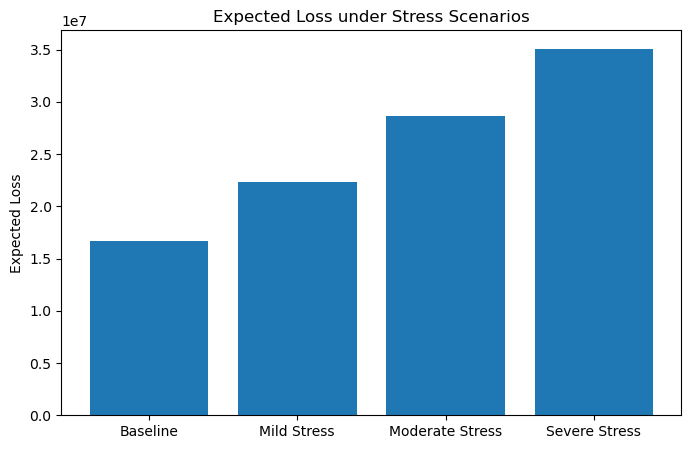

In [149]:
# --- Bar chart --- #
plt.figure(figsize=(8,5))
plt.bar(["Baseline"] + scenarios["Scenario"].tolist(), [el_baseline] + scenarios["Expected Loss"].tolist())
plt.title("Expected Loss under Stress Scenarios")
plt.ylabel("Expected Loss")
plt.show()

**Interpretation of Stress testing Results**

The stress testing analysis evaluates how the Expected Loss(EA) of the credit portfolio changes under different levels of economic deterioration: mild, moderate and severe stress scenarios.

1. General Trend
The results show a clear and consistant increase in the expected loss as economic condition worsen.
As PD, LGD and EAD increase across scenrios:
- Expected Loss rises significantly
- The portfolio becomes increasingly exposed to financial risk

2. Mild Stress Scenario
In the mild stress scenrio:
 - There is a noticeable increase in EL compared to the baseline
 - However, the increase remains relatively manageable
This suggests that:
- the protfolio can absorb small economic shocks
- risk levels increase but remain under control

3. Moderate Stress Scenario
Under modarate stress:
- Expected Loss increases substantially
- The percentage growth be4comes more significant
This indicates:
- rising vulnerability of the portfolio
- growing pressure on the bank's capital

4. Severe Strees Scenario
In the serve stress scenario:
- Expected Loss reaches its highest level
- The increase compared to baseline is dramatic

This reflects:
- high sensitivity if the portfolio to macroeconomic shocks
- strong combined effect of PD, LGD and EAD increases


The analisys demostrates that:
- credit risk is non-linear
- simultaneous increases in PD, LGD and EAD lead to multiplicative effect.

## 10. Sensitivity Analysis

The sensitivity of Expected Loss to its components can be analyzed using: $$ EL = PD \times LGD \times EAD $$

To better understand the impact of each variable the sensitivity of EL can be analyzed using partial derivatives:
$$ \frac{\partial EL}{\partial PD} = LGD \times EAD$$
$$ \frac{\partial EL}{\partial LGD} = PD \times EAD$$
$$ \frac{\partial EL}{\partial EAD} = PD \times LGD$$

Interpretation of the Derivaties

- The sensitivity of EL with respect to PD depends on both LGD and EAD
- The sensitivity with respect to LGD depends on PD and EAD
- The sensitivity with respect to EAD depends on PD and LGD

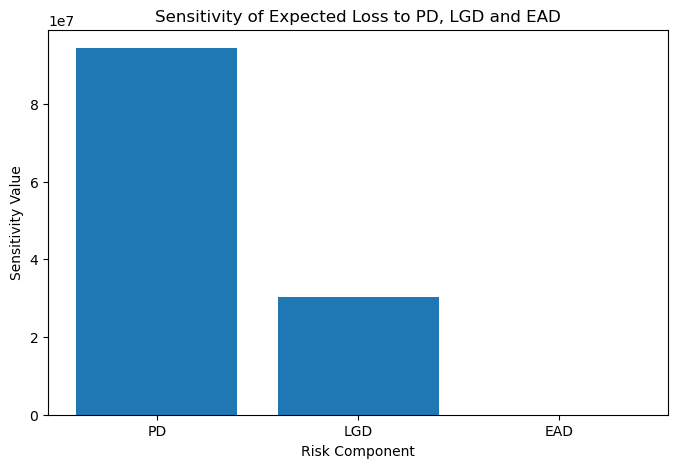

In [150]:
#Sensitivities
sensitivity_pd = average_lgd*total_ead
sensitivity_lgd = probability_default*total_ead
sensitivity_ead = probability_default*average_lgd

#Store values
labels = ["PD", "LGD", "EAD"]
values = [sensitivity_pd, sensitivity_lgd, sensitivity_ead]

#Plot
plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Sensitivity of Expected Loss to PD, LGD and EAD")
plt.ylabel("Sensitivity Value")
plt.xlabel("Risk Component")
plt.show()

In [151]:
print("Sensitivity PD:", sensitivity_pd)
print("Sensitivity LGD:", sensitivity_lgd)
print("Sensitivity EAD:", sensitivity_ead)

Sensitivity PD: 94346311.1490437
Sensitivity LGD: 30266692.962065794
Sensitivity EAD: 0.09691950771323313


The bar char illustrates the sensitivity of Expected Loss to its three main components: PD, LGS and EAD. The results show that EL is most sensitive to changes in PD, followed by LGD while EAD has the smallest marginal effect in derivative form.

A small increase in PD leads to a substantial increase in expected loss because it directly increases the number of borrowers expected to default. This means more defaults => more losses across the entire portfolio.

### Realistic Shock Analysis

Motivation

While partial derivaties show theoretical sensitivity, real-world risk is better understood through scenario analysis.

We simualate realistic changes in the risk parameters:
- PD inv=creases due to economic stress
- LGD increases due to lower recovery rates
- EAD increases due to higher exposure


Baseline: 16636062.66079175
PD shock impact: 4686203.658892127
LGD shock impact: 3026669.2962065805
EAD shock impact: 1663606.266079178


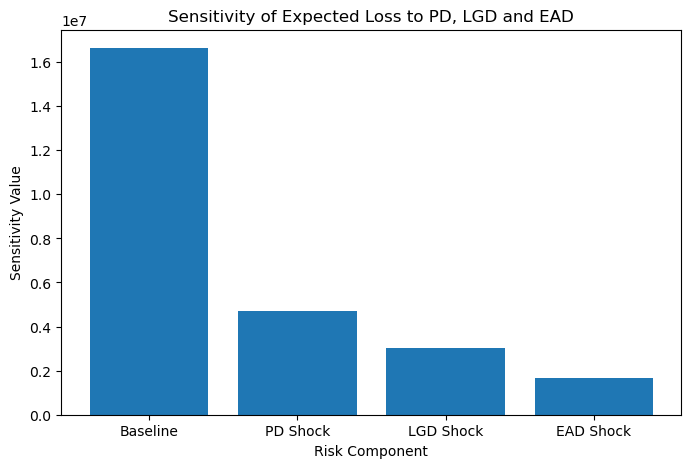

In [152]:
# Shock scenarios
pd_shock = 0.226 # +5 percentage points
lgd_shock = average_lgd + 0.10 # +10 percentage points
ead_shock = total_ead * 1.10 # +10 percentage points

#New EL values
el_pd_shock = pd_shock*average_lgd*total_ead
el_lgd_shock = probability_default*lgd_shock*total_ead
el_ead_shock = probability_default*average_lgd*ead_shock

#Differnces
impact_pd = el_pd_shock - el_baseline
impact_lgd = el_lgd_shock - el_baseline
impact_ead = el_ead_shock - el_baseline

print("Baseline:", el_baseline)
print("PD shock impact:",impact_pd)
print("LGD shock impact:",impact_lgd)
print("EAD shock impact:",impact_ead)

#Plot
labels = ["Baseline", "PD Shock", "LGD Shock", "EAD Shock"]
values = [el_baseline,impact_pd, impact_lgd, impact_ead]
plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Sensitivity of Expected Loss to PD, LGD and EAD")
plt.ylabel("Sensitivity Value")
plt.xlabel("Risk Component")
plt.show()

## 11. Assumptions and Limitations

This analysis is based on several assumptions due to limitations in the available dataset.

Assumptions

- PD estimation is based on historical default rates and assumes that past behavior reflects future risk.
- EAD is approximated using a simulated variable as the dataset does not provide actual outstanding balances.
- LGD is calculated as the ratio of remaining balance to loan amount assuming no recovery information is availble.

Limitations
- The dataset does not include recovery rates, which limits the accuracy of LGD estimation.
- The simulated remaining balance may not fully reflect real repayment behavior.
- The analysis does not include macroeconomic variables such as unemployment or inflation.
- The PD calculation is not segment by borrower characteristics which may oversimplify risk differences.

## 12. Final Conclusion


This project analyzed credit risk using the key components Probability of Default(PD), Loss Given Default(LGD) and Exposure at Default(EAD). The results show that the portfolio is exposed to a moderate probability of default, combined with high loss severity and significant exposure at risk.

the calculation of the expected loss demonstrates that even under normal conditions, the bank faces substantial potential losses. Furthermore, the stress testing analysis reveals that under adverse economic scenarios, expected losses can increase dramatically - potentially more than doublilng. This highlights the strong sensitivity of credit risk to changes in macroeconomic conditions.

Overall, the findings emphasize the importance of:
- effective credit risk assessment
- borrower segmentation
- and proactive risk management strategies

In conclusion, managing credit risk requires not only analyzing current portfolio characteristics but also anticipating how economic shocks can amplify financial losses.

### References

1. Medium.(2024). Credit Risk Modeling in Python https://medium.com/@danrlei.diegues_91903/credit-risk-modeling-in-python-e9b2379ebeb0
2. GeeksForGeeks.(2025) Probability of Default https://www.geeksforgeeks.org/maths/probability-of-default/